Prêt ! Modèle configuré avec 58 variables après encodage.

================ RÉSULTATS ISOLÉS ================
Précision globale (Accuracy) : 51.55%

                    precision    recall  f1-score   support

Blessé hospitalisé       0.40      0.27      0.32      2643
      Blessé léger       0.75      0.64      0.69      4864
               Tué       0.15      0.56      0.24       580

          accuracy                           0.52      8087
         macro avg       0.43      0.49      0.42      8087
      weighted avg       0.59      0.52      0.54      8087


================ VALIDATION CROISÉE ================
Scores pour chaque pli : [0.52426584 0.52812983 0.51530139 0.51507188 0.52867522]
Exactitude moyenne : 52.23%
Stabilité (écart-type) : 0.0060



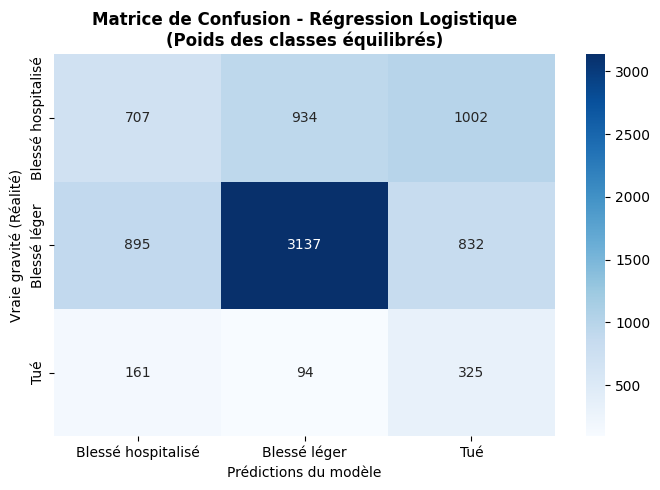

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Chargement du dataset commun propre
base_path = Path.cwd().parent
data_path = base_path / 'data' / 'accidents_2024_clean_base.csv'
df = pd.read_csv(data_path, sep=';', encoding='utf-8')

# 2. Séparation des caractéristiques (X) et de la cible (y)
X_raw = df.drop(columns=['Num_Acc', 'Département', 'Gravité (label)'])
y = df['Gravité (label)']

# 3. Préparation Spécifique : One-Hot Encoding
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# 4. Séparation Train / Test (80% / 20%) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Normalisation stricte (indispensable pour la Régression Logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Prêt ! Modèle configuré avec {X_train_scaled.shape[1]} variables après encodage.")

# 6. Entraînement du modèle (avec poids équilibrés)
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# 7. Évaluation des performances isolées
y_pred = model.predict(X_test_scaled)

print("\n================ RÉSULTATS ISOLÉS ================")
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred))

# 8. Validation Croisée (Stratified 5-Fold)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, scoring='accuracy')

print("\n================ VALIDATION CROISÉE ================")
print(f"Scores pour chaque pli : {cv_scores}")
print(f"Exactitude moyenne : {cv_scores.mean():.2%}")
print(f"Stabilité (écart-type) : {cv_scores.std():.4f}\n")

# 9. Génération et affichage de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
labels_ordonnes = sorted(y_test.unique())

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_ordonnes, 
            yticklabels=labels_ordonnes)

plt.title('Matrice de Confusion - Régression Logistique\n(Poids des classes équilibrés)', fontsize=12, fontweight='bold')
plt.xlabel('Prédictions du modèle')
plt.ylabel('Vraie gravité (Réalité)')
plt.tight_layout()
plt.show()

In [ ]:
# Afficher les coefficients les plus importants
coefficients = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Coefficient': model.coef_[2] # Index 2 correspond généralement à la classe "Tué"
})
print(coefficients.sort_values(by='Coefficient', ascending=False).head(10))

                                             Variable  Coefficient
1                               Vitesse max autorisée     0.199201
26            Catégorie de route_Route départementale     0.184010
2                    Agglomération_Hors agglomération     0.151901
5               Luminosité_Nuit sans éclairage public     0.122661
28                  Catégorie de route_Voie communale     0.084073
40                         État de la surface_Normale     0.081733
24  Catégorie de route_Parking ouvert à la circula...     0.070750
25      Catégorie de route_Route de métropole urbaine     0.061719
6                               Luminosité_Plein jour     0.061055
49                         Infrastructure_Voie ferrée     0.056158


In [ ]:
# ==== SAUVEGARDE DES DONNÉES SPÉCIFIQUES À LA RÉGRESSION LOGISTIQUE ====

# Création d'un sous-dossier spécifique si nécessaire ou sauvegarde directe dans 'data'
X_train_df = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

X_train_df.to_csv(base_path / 'data' / 'X_train_lr.csv', index=False)
X_test_df.to_csv(base_path / 'data' / 'X_test_lr.csv', index=False)
y_train.to_csv(base_path / 'data' / 'y_train_lr.csv', index=False)
y_test.to_csv(base_path / 'data' / 'y_test_lr.csv', index=False)

print("Vos fichiers d'entraînement et de test (propres à la Régression Logistique) ont été sauvegardés !")

Vos fichiers d'entraînement et de test (propres à la Régression Logistique) ont été sauvegardés !


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Configuration d'une validation croisée stratifiée à 5 plis
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, scoring='accuracy')

print("\n================ VALIDATION CROISÉE ================")
print(f"Scores pour chaque pli : {cv_scores}")
print(f"Exactitude moyenne : {cv_scores.mean():.2%}")
print(f"Stabilité (écart-type) : {cv_scores.std():.4f}\n")


================ VALIDATION CROISÉE ================
Scores pour chaque pli : [0.52426584 0.52812983 0.51530139 0.51507188 0.52867522]
Exactitude moyenne : 52.23%
Stabilité (écart-type) : 0.0060



In [ ]:
# Trouver l'index correspondant à la classe "Tué" dans ton modèle
index_tue = list(model.classes_).index('Tué')

# Associer les variables à leurs coefficients associés
coefficients_tue = pd.DataFrame({
    'Facteur (Variable)': X_encoded.columns,
    'Coefficient (Impact)': model.coef_[index_tue]
})

print("---------- TOP 5 DES FACTEURS AGGRAVANTS (AUGMENTENT LE RISQUE DE MORT) ----------")
print(coefficients_tue.sort_values(by='Coefficient (Impact)', ascending=False).head(5).to_string(index=False))

print("\n---------- TOP 5 DES FACTEURS PROTECTEURS (DIMINUENT LE RISQUE DE MORT) ----------")
print(coefficients_tue.sort_values(by='Coefficient (Impact)', ascending=True).head(5).to_string(index=False))

---------- TOP 5 DES FACTEURS AGGRAVANTS (AUGMENTENT LE RISQUE DE MORT) ----------
                     Facteur (Variable)  Coefficient (Impact)
                  Vitesse max autorisée              0.199201
Catégorie de route_Route départementale              0.184010
       Agglomération_Hors agglomération              0.151901
  Luminosité_Nuit sans éclairage public              0.122661
      Catégorie de route_Voie communale              0.084073

---------- TOP 5 DES FACTEURS PROTECTEURS (DIMINUENT LE RISQUE DE MORT) ----------
                            Facteur (Variable)  Coefficient (Impact)
   Type de collision_2 véhicules - par le côté             -0.267117
 Type de collision_2 véhicules - par larrière             -0.186806
             Régime de circulation_Sens unique             -0.162295
Type de collision_3 véhicules et + - en chaîne             -0.138511
           Régime de circulation_Non renseigné             -0.113603
